# Bangladesh Budget Impact Analysis, v2

Goal: evaluate whether Bangladesh budgets from FY2010–11 to FY2025–26 were good for the economy and people.

This version includes:

1. Budget trend
2. Fiscal deficit/revenue template
3. CPI, GDP, unemployment, exchange rate, reserves, money supply, revenue % GDP, expense % GDP, debt % GDP from World Bank
4. Correlation and regression
5. Budget Effectiveness Score v2
6. Corruption / public spending risk module template


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import statsmodels.api as sm
from pathlib import Path

DATA = Path("data")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 150)


## 1. Load Budget Data

In [2]:
budget = pd.read_csv(DATA / "bangladesh_budget_2010_2025.csv")
budget


,FiscalYear,Year,BudgetCroreBDT,BudgetGrowthPct
0,2010-11,2010,132170,NaN
1,2011-12,2011,161214,21.974730
2,2012-13,2012,191738,18.933839
3,2013-14,2013,222491,16.039074
4,2014-15,2014,250560,12.615791
5,2015-16,2015,295100,17.776181
6,2016-17,2016,340605,15.420197
7,2017-18,2017,400266,17.516184
8,2018-19,2018,464573,16.066066
9,2019-20,2019,523190,12.617393


## 2. Load Fiscal Manual Template

This file contains columns for revenue, deficit, ADP, sector allocations, interest payments, and source notes. Only use verified numbers. Do not fill from memory.

In [3]:
fiscal = pd.read_csv(DATA / "bangladesh_fiscal_manual_verified_template.csv")
fiscal


,FiscalYear,Year,BudgetCroreBDT,RevenueTargetCroreBDT,NBRRevenueTargetCroreBDT,TotalDeficitCroreBDT,DeficitPctGDP,ADPCroreBDT,HealthAllocationCroreBDT,EducationAllocationCroreBDT,SocialSafetyNetCroreBDT,InterestPaymentCroreBDT,SourceURL,SourceNote
0,2010-11,2010,132170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011-12,2011,161214,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2012-13,2012,191738,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2013-14,2013,222491,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-15,2014,250560,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2015-16,2015,295100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2016-17,2016,340605,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2017-18,2017,400266,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2018-19,2018,464573,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2019-20,2019,523190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Fetch World Bank Macro Indicators

In [4]:
INDICATORS = {
    "InflationCPI": "FP.CPI.TOTL.ZG",
    "GDPGrowth": "NY.GDP.MKTP.KD.ZG",
    "Unemployment": "SL.UEM.TOTL.ZS",
    "PovertyNational": "SI.POV.NAHC",
    "ExchangeRateLCUPerUSD": "PA.NUS.FCRF",
    "TotalReservesUSD": "FI.RES.TOTL.CD",
    "BroadMoneyGrowth": "FM.LBL.BMNY.ZG",
    "GovtExpensePctGDP": "GC.XPN.TOTL.GD.ZS",
    "GovtRevenuePctGDP": "GC.REV.XGRT.GD.ZS",
    "CentralGovtDebtPctGDP": "GC.DOD.TOTL.GD.ZS",
}

def fetch_world_bank_indicator(country_code, indicator, start_year=2010, end_year=2025):
    url = f"https://api.worldbank.org/v2/country/{country_code}/indicator/{indicator}"
    params = {"format": "json", "per_page": 100, "date": f"{start_year}:{end_year}"}
    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()
    payload = response.json()
    if len(payload) < 2 or payload[1] is None:
        return pd.DataFrame(columns=["Year", indicator])
    rows = [{"Year": int(item["date"]), indicator: item["value"]} for item in payload[1]]
    return pd.DataFrame(rows).sort_values("Year")

macro = None
for col, indicator in INDICATORS.items():
    temp = fetch_world_bank_indicator("BGD", indicator).rename(columns={indicator: col})
    macro = temp if macro is None else macro.merge(temp, on="Year", how="outer")

macro = macro.sort_values("Year")
macro.to_csv(DATA / "bangladesh_world_bank_macro_2010_2025.csv", index=False)
macro


,Year,InflationCPI,GDPGrowth,Unemployment,PovertyNational,ExchangeRateLCUPerUSD,TotalReservesUSD,BroadMoneyGrowth,GovtExpensePctGDP,GovtRevenuePctGDP,CentralGovtDebtPctGDP
0,2010,8.126676,5.571788,3.379,NaN,69.649292,1.117483e+10,21.078858,9.266251,9.743829,None
1,2011,11.395165,6.464379,3.737,NaN,74.152400,9.174750e+09,16.915368,9.843885,10.462657,None
2,2012,6.217504,6.521459,4.070,NaN,81.862658,1.275423e+10,17.011323,9.638539,11.145230,None
3,2013,7.530406,6.013606,4.426,NaN,78.103235,1.808769e+10,14.849813,9.507120,11.160412,None
4,2014,6.991639,6.061059,4.417,NaN,77.641408,2.231979e+10,15.610216,9.504436,10.866886,None
5,2015,6.194280,6.552640,4.397,NaN,77.946908,2.749308e+10,14.892336,9.005885,9.844484,None
6,2016,5.513526,7.113478,4.350,NaN,78.468092,3.228384e+10,16.697757,7.862768,8.522796,None
7,2017,5.702070,6.590250,4.372,NaN,80.437542,3.343148e+10,13.739396,7.639874,8.071263,None
8,2018,5.543621,7.319413,4.439,NaN,83.466202,3.202838e+10,11.506169,7.494145,8.704805,None
9,2019,5.591996,7.881915,4.504,NaN,84.453523,3.269694e+10,11.905266,8.272316,8.855780,None


## 4. Merge Budget + Fiscal + Macro

In [5]:
# Reload macro from file after fetch
macro = pd.read_csv(DATA / "bangladesh_world_bank_macro_2010_2025.csv")

df = budget.merge(fiscal.drop(columns=["BudgetCroreBDT"]), on=["FiscalYear", "Year"], how="left")
df = df.merge(macro, on="Year", how="left")

# Convert manual numeric columns safely
manual_numeric_cols = [
    "RevenueTargetCroreBDT", "NBRRevenueTargetCroreBDT", "TotalDeficitCroreBDT",
    "DeficitPctGDP", "ADPCroreBDT", "HealthAllocationCroreBDT",
    "EducationAllocationCroreBDT", "SocialSafetyNetCroreBDT", "InterestPaymentCroreBDT"
]
for col in manual_numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["BudgetToRevenueGapCroreBDT"] = df["BudgetCroreBDT"] - df["RevenueTargetCroreBDT"]
df["BudgetRealGrowthApprox"] = df["BudgetGrowthPct"] - df["InflationCPI"]

df


,FiscalYear,Year,BudgetCroreBDT,BudgetGrowthPct,RevenueTargetCroreBDT,NBRRevenueTargetCroreBDT,TotalDeficitCroreBDT,DeficitPctGDP,ADPCroreBDT,HealthAllocationCroreBDT,EducationAllocationCroreBDT,SocialSafetyNetCroreBDT,InterestPaymentCroreBDT,SourceURL,SourceNote,InflationCPI,GDPGrowth,Unemployment,PovertyNational,ExchangeRateLCUPerUSD,TotalReservesUSD,BroadMoneyGrowth,GovtExpensePctGDP,GovtRevenuePctGDP,CentralGovtDebtPctGDP,BudgetToRevenueGapCroreBDT,BudgetRealGrowthApprox
0,2010-11,2010,132170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.126676,5.571788,3.379,NaN,69.649292,1.117483e+10,21.078858,9.266251,9.743829,NaN,NaN,NaN
1,2011-12,2011,161214,21.974730,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.395165,6.464379,3.737,NaN,74.152400,9.174750e+09,16.915368,9.843885,10.462657,NaN,NaN,10.579564
2,2012-13,2012,191738,18.933839,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.217504,6.521459,4.070,NaN,81.862658,1.275423e+10,17.011323,9.638539,11.145230,NaN,NaN,12.716335
3,2013-14,2013,222491,16.039074,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.530406,6.013606,4.426,NaN,78.103235,1.808769e+10,14.849813,9.507120,11.160412,NaN,NaN,8.508668
4,2014-15,2014,250560,12.615791,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.991639,6.061059,4.417,NaN,77.641408,2.231979e+10,15.610216,9.504436,10.866886,NaN,NaN,5.624152
5,2015-16,2015,295100,17.776181,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.194280,6.552640,4.397,NaN,77.946908,2.749308e+10,14.892336,9.005885,9.844484,NaN,NaN,11.581901
6,2016-17,2016,340605,15.420197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.513526,7.113478,4.350,NaN,78.468092,3.228384e+10,16.697757,7.862768,8.522796,NaN,NaN,9.906671
7,2017-18,2017,400266,17.516184,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.702070,6.590250,4.372,NaN,80.437542,3.343148e+10,13.739396,7.639874,8.071263,NaN,NaN,11.814114
8,2018-19,2018,464573,16.066066,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.543621,7.319413,4.439,NaN,83.466202,3.202838e+10,11.506169,7.494145,8.704805,NaN,NaN,10.522445
9,2019-20,2019,523190,12.617393,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.591996,7.881915,4.504,NaN,84.453523,3.269694e+10,11.905266,8.272316,8.855780,NaN,NaN,7.025396


## 5. Core Charts

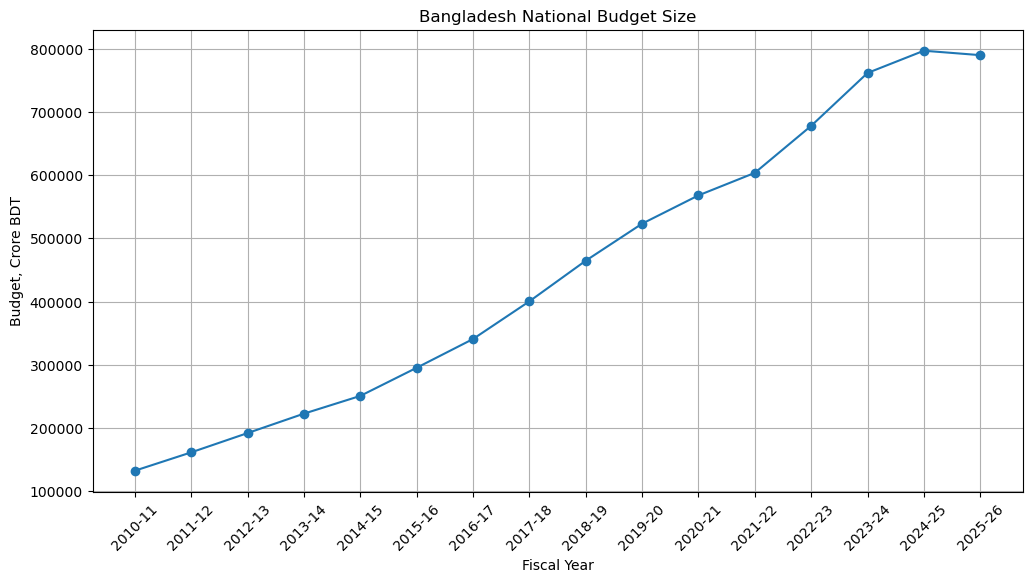

In [6]:
plt.plot(df["FiscalYear"], df["BudgetCroreBDT"], marker="o")
plt.title("Bangladesh National Budget Size")
plt.xlabel("Fiscal Year")
plt.ylabel("Budget, Crore BDT")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


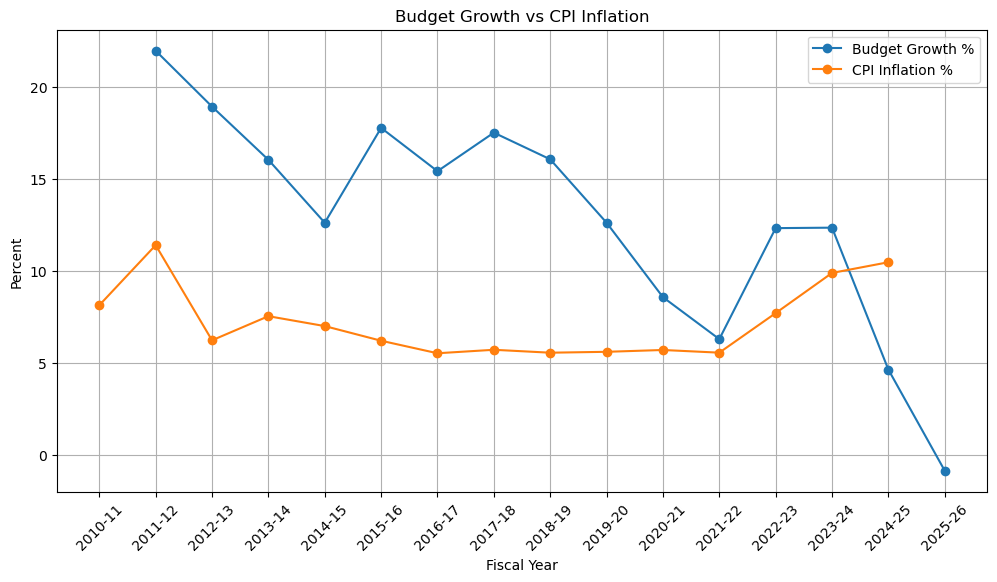

In [7]:
plt.plot(df["FiscalYear"], df["BudgetGrowthPct"], marker="o", label="Budget Growth %")
plt.plot(df["FiscalYear"], df["InflationCPI"], marker="o", label="CPI Inflation %")
plt.title("Budget Growth vs CPI Inflation")
plt.xlabel("Fiscal Year")
plt.ylabel("Percent")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()


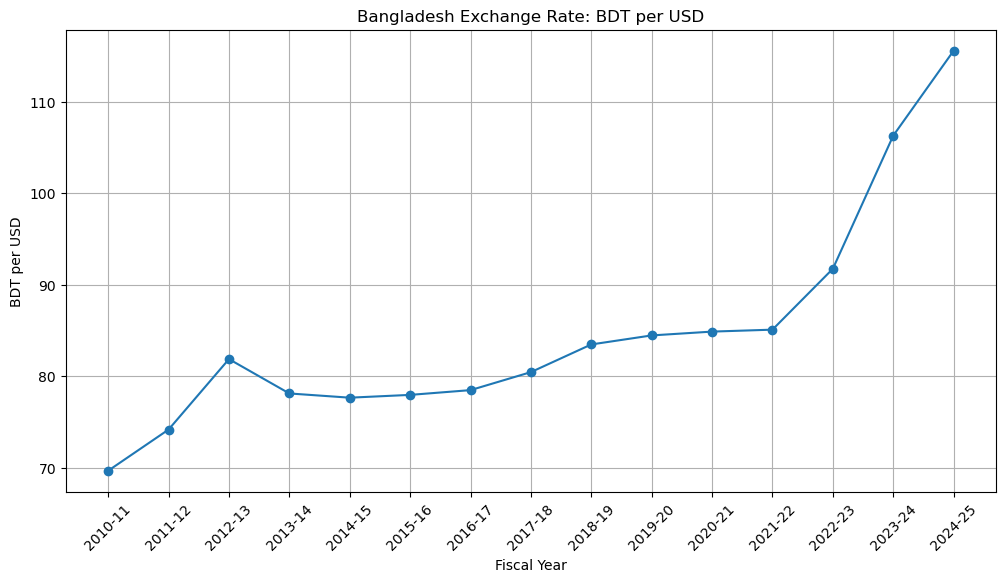

In [8]:
plt.plot(df["FiscalYear"], df["ExchangeRateLCUPerUSD"], marker="o")
plt.title("Bangladesh Exchange Rate: BDT per USD")
plt.xlabel("Fiscal Year")
plt.ylabel("BDT per USD")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


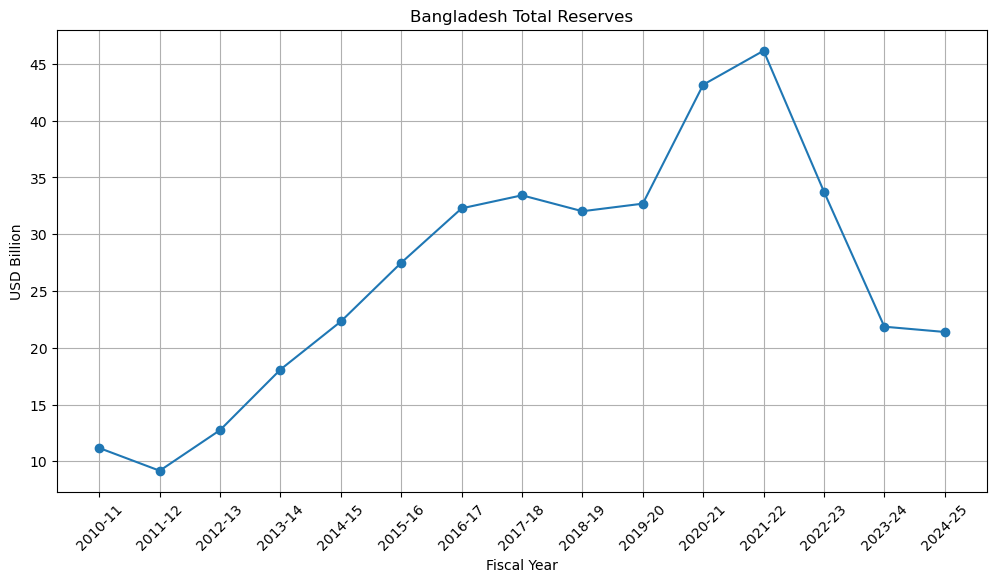

In [9]:
plt.plot(df["FiscalYear"], df["TotalReservesUSD"] / 1e9, marker="o")
plt.title("Bangladesh Total Reserves")
plt.xlabel("Fiscal Year")
plt.ylabel("USD Billion")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


## 6. Correlation Matrix

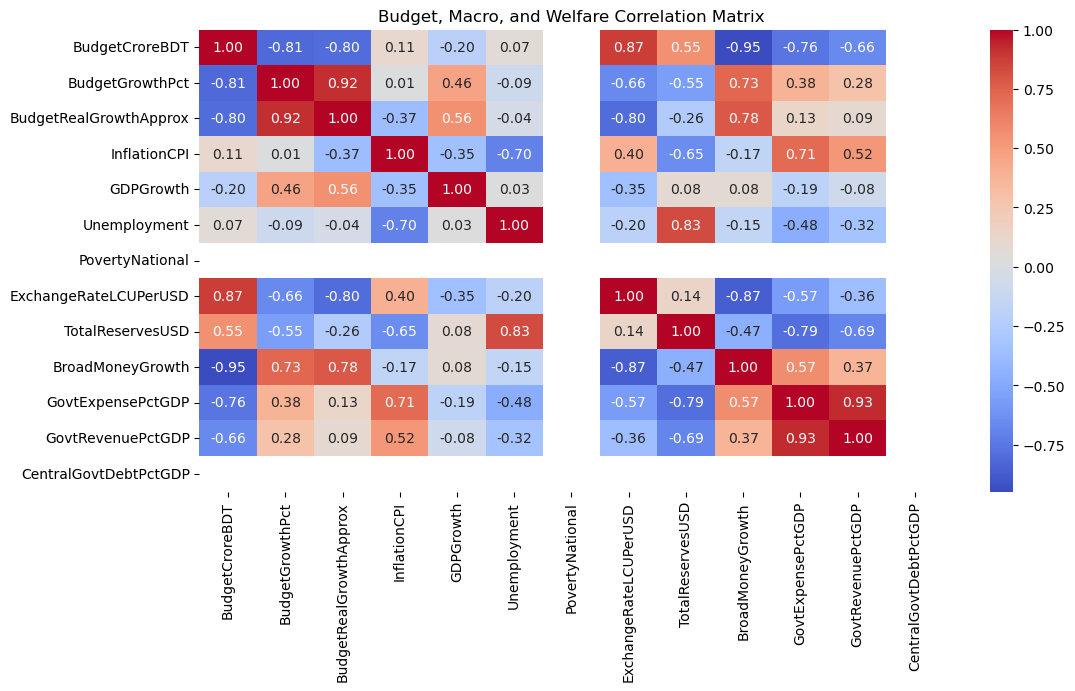

,InflationCPI,GDPGrowth
InflationCPI,1.000000,-0.347282
GovtExpensePctGDP,0.713266,-0.187619
GovtRevenuePctGDP,0.522094,-0.078860
ExchangeRateLCUPerUSD,0.398254,-0.347527
BudgetCroreBDT,0.105107,-0.204664
BudgetGrowthPct,0.014102,0.460061
BroadMoneyGrowth,-0.170136,0.077823
GDPGrowth,-0.347282,1.000000
BudgetRealGrowthApprox,-0.371181,0.555471
TotalReservesUSD,-0.649793,0.082895


In [10]:
corr_cols = [
    "BudgetCroreBDT", "BudgetGrowthPct", "BudgetRealGrowthApprox",
    "InflationCPI", "GDPGrowth", "Unemployment", "PovertyNational",
    "ExchangeRateLCUPerUSD", "TotalReservesUSD", "BroadMoneyGrowth",
    "GovtExpensePctGDP", "GovtRevenuePctGDP", "CentralGovtDebtPctGDP"
]
corr = df[corr_cols].corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Budget, Macro, and Welfare Correlation Matrix")
plt.show()

corr[["InflationCPI", "GDPGrowth"]].sort_values("InflationCPI", ascending=False)


## 7. Regression: Inflation Drivers

This model tests whether inflation is more related to budget growth, exchange-rate depreciation, money supply, reserves, and unemployment. This is better than a simple Budget vs CPI model.

In [11]:
reg_cols = [
    "InflationCPI", "BudgetGrowthPct", "GDPGrowth", "Unemployment",
    "ExchangeRateLCUPerUSD", "BroadMoneyGrowth", "TotalReservesUSD"
]
reg_df = df[reg_cols].dropna().copy()
reg_df["TotalReservesUSDBillion"] = reg_df["TotalReservesUSD"] / 1e9

X = reg_df[["BudgetGrowthPct", "GDPGrowth", "Unemployment", "ExchangeRateLCUPerUSD", "BroadMoneyGrowth", "TotalReservesUSDBillion"]]
X = sm.add_constant(X)
y = reg_df["InflationCPI"]

inflation_model = sm.OLS(y, X).fit()
print(inflation_model.summary())


                            OLS Regression Results                            
Dep. Variable:           InflationCPI   R-squared:                       0.856
Model:                            OLS   Adj. R-squared:                  0.732
Method:                 Least Squares   F-statistic:                     6.920
Date:                Sun, 14 Jun 2026   Prob (F-statistic):             0.0111
Time:                        03:24:05   Log-Likelihood:                -15.661
No. Observations:                  14   AIC:                             45.32
Df Residuals:                       7   BIC:                             49.80
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

/Users/jerin/miniconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=14
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


## 8. Budget Effectiveness Score v2

Score idea:

- Economic score: GDP growth, inflation control
- People score: unemployment, poverty when available
- Fiscal score: revenue strength, debt control, reserve strength

This is a portfolio metric, not an official government metric.

In [12]:
score = df.copy()

def norm_pos(s):
    s = s.astype(float)
    return (s - s.min()) / (s.max() - s.min())

def norm_neg(s):
    s = s.astype(float)
    return 1 - ((s - s.min()) / (s.max() - s.min()))

score["GDPScore"] = norm_pos(score["GDPGrowth"])
score["InflationControlScore"] = norm_neg(score["InflationCPI"])
score["EmploymentScore"] = norm_neg(score["Unemployment"])
score["ReserveScore"] = norm_pos(score["TotalReservesUSD"])
score["DebtControlScore"] = norm_neg(score["CentralGovtDebtPctGDP"])
score["RevenueScore"] = norm_pos(score["GovtRevenuePctGDP"])

score["EconomicScore"] = (0.55 * score["GDPScore"] + 0.45 * score["InflationControlScore"]) * 100
score["PeopleScore"] = score["EmploymentScore"] * 100
score["FiscalScore"] = (
    0.40 * score["ReserveScore"] +
    0.30 * score["DebtControlScore"] +
    0.30 * score["RevenueScore"]
) * 100

score["BudgetEffectivenessScoreV2"] = (
    0.40 * score["EconomicScore"] +
    0.30 * score["PeopleScore"] +
    0.30 * score["FiscalScore"]
)

score[[
    "FiscalYear", "BudgetCroreBDT", "InflationCPI", "GDPGrowth",
    "Unemployment", "ExchangeRateLCUPerUSD", "CentralGovtDebtPctGDP",
    "BudgetEffectivenessScoreV2"
]]


,FiscalYear,BudgetCroreBDT,InflationCPI,GDPGrowth,Unemployment,ExchangeRateLCUPerUSD,CentralGovtDebtPctGDP,BudgetEffectivenessScoreV2
0,2010-11,132170,8.126676,5.571788,3.379,69.649292,NaN,NaN
1,2011-12,161214,11.395165,6.464379,3.737,74.152400,NaN,NaN
2,2012-13,191738,6.217504,6.521459,4.070,81.862658,NaN,NaN
3,2013-14,222491,7.530406,6.013606,4.426,78.103235,NaN,NaN
4,2014-15,250560,6.991639,6.061059,4.417,77.641408,NaN,NaN
5,2015-16,295100,6.194280,6.552640,4.397,77.946908,NaN,NaN
6,2016-17,340605,5.513526,7.113478,4.350,78.468092,NaN,NaN
7,2017-18,400266,5.702070,6.590250,4.372,80.437542,NaN,NaN
8,2018-19,464573,5.543621,7.319413,4.439,83.466202,NaN,NaN
9,2019-20,523190,5.591996,7.881915,4.504,84.453523,NaN,NaN


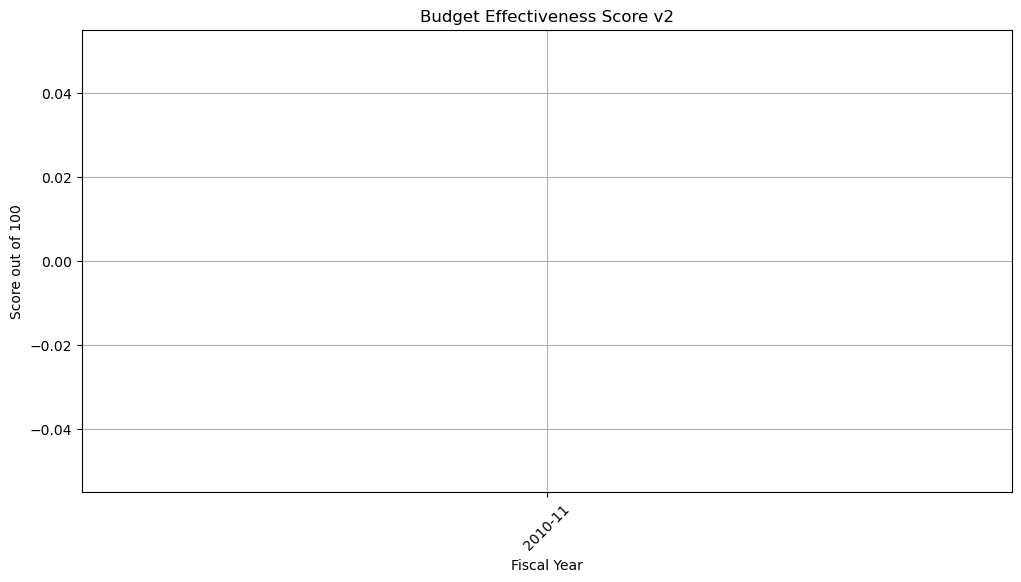

In [13]:
plt.plot(score["FiscalYear"], score["BudgetEffectivenessScoreV2"], marker="o")
plt.title("Budget Effectiveness Score v2")
plt.xlabel("Fiscal Year")
plt.ylabel("Score out of 100")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


## 9. Good / Bad Budget Classification

In [14]:
def classify_budget(score):
    if pd.isna(score):
        return "Insufficient data"
    if score >= 80:
        return "Strong"
    if score >= 65:
        return "Moderate"
    if score >= 50:
        return "Weak"
    return "Poor"

score["BudgetQualityLabel"] = score["BudgetEffectivenessScoreV2"].apply(classify_budget)

score[["FiscalYear", "BudgetEffectivenessScoreV2", "BudgetQualityLabel"]].sort_values(
    "BudgetEffectivenessScoreV2", ascending=False
)


,FiscalYear,BudgetEffectivenessScoreV2,BudgetQualityLabel
0,2010-11,NaN,Insufficient data
1,2011-12,NaN,Insufficient data
2,2012-13,NaN,Insufficient data
3,2013-14,NaN,Insufficient data
4,2014-15,NaN,Insufficient data
5,2015-16,NaN,Insufficient data
6,2016-17,NaN,Insufficient data
7,2017-18,NaN,Insufficient data
8,2018-19,NaN,Insufficient data
9,2019-20,NaN,Insufficient data


## 10. Corruption / Public Spending Risk Module

This does not prove corruption. It flags risk indicators from project-level data.

Risk indicators:

- high cost overrun
- long completion delay
- single-bid procurement
- repeated contractor wins
- audit objections


In [15]:
projects = pd.read_csv(DATA / "public_project_corruption_risk_template.csv")

# Example rows; replace with verified project data.
example_projects = pd.DataFrame({
    "ProjectName": ["Project A", "Project B", "Project C"],
    "Sector": ["Transport", "Health", "Education"],
    "ApprovalYear": [2018, 2019, 2020],
    "EstimatedCostCroreBDT": [1000, 500, 300],
    "RevisedCostCroreBDT": [2500, 900, 330],
    "ActualCostCroreBDT": [2600, 950, 340],
    "EstimatedCompletionYear": [2021, 2021, 2022],
    "ActualCompletionYear": [2024, 2023, 2022],
    "ProcurementMethod": ["Open Tender", "Limited Tender", "Open Tender"],
    "NumberOfBidders": [1, 2, 8],
    "WinningContractor": ["Contractor X", "Contractor Y", "Contractor Z"],
    "AuditObjectionCroreBDT": [100, 25, 0],
    "SourceURL": ["", "", ""],
    "SourceNote": ["Example only", "Example only", "Example only"]
})

projects = example_projects.copy()

projects["CostOverrunPct"] = (
    (projects["ActualCostCroreBDT"] - projects["EstimatedCostCroreBDT"])
    / projects["EstimatedCostCroreBDT"]
) * 100

projects["DelayYears"] = projects["ActualCompletionYear"] - projects["EstimatedCompletionYear"]

projects["SingleBidFlag"] = projects["NumberOfBidders"].apply(lambda x: 1 if x <= 1 else 0)
projects["HighCostOverrunFlag"] = projects["CostOverrunPct"].apply(lambda x: 1 if x >= 50 else 0)
projects["DelayFlag"] = projects["DelayYears"].apply(lambda x: 1 if x >= 2 else 0)
projects["AuditFlag"] = projects["AuditObjectionCroreBDT"].apply(lambda x: 1 if x > 0 else 0)

projects["RiskScore"] = (
    35 * projects["HighCostOverrunFlag"] +
    25 * projects["DelayFlag"] +
    25 * projects["SingleBidFlag"] +
    15 * projects["AuditFlag"]
)

projects.sort_values("RiskScore", ascending=False)


,ProjectName,Sector,ApprovalYear,EstimatedCostCroreBDT,RevisedCostCroreBDT,ActualCostCroreBDT,EstimatedCompletionYear,ActualCompletionYear,ProcurementMethod,NumberOfBidders,WinningContractor,AuditObjectionCroreBDT,SourceURL,SourceNote,CostOverrunPct,DelayYears,SingleBidFlag,HighCostOverrunFlag,DelayFlag,AuditFlag,RiskScore
0,Project A,Transport,2018,1000,2500,2600,2021,2024,Open Tender,1,Contractor X,100,,Example only,160.000000,3,1,1,1,1,100
1,Project B,Health,2019,500,900,950,2021,2023,Limited Tender,2,Contractor Y,25,,Example only,90.000000,2,0,1,1,1,75
2,Project C,Education,2020,300,330,340,2022,2022,Open Tender,8,Contractor Z,0,,Example only,13.333333,0,0,0,0,0,0


## 11. Next Step Checklist

Fill verified data in `bangladesh_fiscal_manual_verified_template.csv`:

1. Revenue target 2010–2025
2. Deficit 2010–2025
3. ADP 2010–2025
4. Health allocation
5. Education allocation
6. Social safety net
7. Interest payment

Then re-run this notebook.